This document has been completed individually. All work is the sole effort, unless otherwise noted, of myself Mason Wakefield.

# Review of Part 2

In part 2, I modeled an RC circuit with a fast transient. This model was done using a constant step size backward Euler method with Newton-Raphson included.

The specific parameters were as follows:

| Parameter | Symbol | Value | Units | Description |
|-----------|--------|-------|-------|-------------|
| Resistance | R | 100 | Ω | Circuit resistance |
| Capacitance | C | 1e-9 | F | Capacitor value |
| Time Constant | RC | 1e-7 | s | Fast transient time |
| Initial Voltage | V(0) | 0 | V | Initially uncharged capacitor |
| Source Voltage | Vs(t) | 5 sin(t) | V | Slowly varying input |
| Angular Frequency | ω | 1 | rad/s | Slow forcing frequency |

This resulted in a stiff equation because the fast decay time scale $\tau_{fast} = \frac{1}{10^7}$ and the forcing time scale $\tau_{slow} \sim 1$. So, $$\text{stiffness ratio} \sim \frac{\tau_{slow}}{\tau_{fast}} = \frac{1}{10^{-7}} = 10^7$$

Final notes: The implicit method was significant because extremely accurate results were generated with step sizes as large as 0.1 (over the time interval 0-10 seconds). This meant the ODE could be solved with many orders of magnitude fewer function calls in our program. Bonus fact: Newton-Raphson converged at a constant rate due to the linearity of the ODE.

# Newton-Raphson Damping Implementation

We must first import the necessary libraries and reproduce the ODE from Part 2 so this notebook is self-contained.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# RC circuit parameters
t_start = 0      # s
t_end   = 10     # s
V_0     = 0.0    # V  (initially uncharged capacitor)

# Python function for our ODE
def dVdt(t, V):
    return -1e7 * V + 1e7 * 5 * np.sin(t)

# Derivative is constant for this linear problem
def g_prime(h):
    return 1 + h * 1e7

Recall that at each Newton-Raphson iteration, the solver computes a full step directly toward the root of the residual. This works well when the initial guess is already close to the solution, but can fail spectacularly when it isn't. In our Backward Euler context, the initial guess for $V_{n+1}$ is the explicit Euler predictor, which becomes increasingly unreliable as the step size h grows large. When this guess is far from the true solution, the full Newton step can overshoot the root and cause the iteration to diverge rather than converge.

Damped Newton-Raphson addresses this by scaling the Newton step with a damping factor $\alpha \in (0, 1]$ before applying it:
$$V^{(k+1)} = V^{(k)} - \alpha \frac{g(V^{(k)})}{g'(V^{(k)})}$$

When $\alpha = 1$ this reduces to the standard Newton-Raphson update, so there is no penalty when the method is already working well. The role of $\alpha$ is simply to shorten the step when a full step would cause the residual to grow rather than shrink.

We will use a backtracking line search to choose $\alpha$. At each iteration we first try the full Newton step $\alpha = 1$. We then evaluate the residual at the proposed new point and check whether it has decreased. If it has, we accept the step immediately. If not, we halve $\alpha$ and try again, repeating until either the residual decreases or $\alpha$ falls below a small threshold (e.g. $10^{-8}$), at which point no further progress is possible and we accept anyway. This guarantees that every accepted step is a genuine improvement, which is what makes the damped solver more robust than its undamped counterpart — particularly at the large step sizes we will test below.

In [2]:
# Original Newton-Raphson with tracking, for comparison
def NewtonRaphsonBasic(f, V, t, h, tol=1e-6, max_iter=50):
    V_next = V + h * f(t, V)  # Explicit Euler predictor as initial guess
    for k in range(1, max_iter + 1):
        g_val = V_next - V - h * f(t + h, V_next)
        V_new = V_next - g_val / g_prime(h)
        if abs(V_new - V_next) < tol:
            return V_new, k, False
        V_next = V_new
    return V_next, max_iter, False

# Damped Newton-Raphson with line search
def NewtonRaphsonDamped(f, V, t, h, tol=1e-6, max_iter=50, alpha_min=1e-8):
    V_next = V + h * f(t, V)  # Explicit Euler predictor as initial guess
    total_backtracks = 0
    damping_used = False

    for k in range(1, max_iter + 1):
        g_val = V_next - V - h * f(t + h, V_next)

        # Full Newton step
        delta = -g_val / g_prime(h)

        # Line search
        alpha = 1.0
        g_current = abs(g_val)
        backtracks = 0

        while True:
            V_candidate = V_next + alpha * delta
            g_candidate = abs(V_candidate - V - h * f(t + h, V_candidate))

            if g_candidate < g_current:   # residual decreased, accept
                break
            if alpha < alpha_min:          # alpha too small, stop halving
                break

            alpha /= 2.0
            backtracks += 1
            damping_used = True            

        total_backtracks += backtracks
        V_new = V_next + alpha * delta

        if abs(V_new - V_next) < tol:
            return V_new, k, total_backtracks, damping_used
        V_next = V_new

    return V_next, max_iter, total_backtracks, damping_used

In [3]:
# Backward Euler using basic Newton-Raphson
def BackwardEulerBasic(f, V_0, t_start, t_end, h):
    t_values = np.arange(t_start, t_end + h, h)
    V_values = np.zeros(len(t_values))
    V_values[0] = V_0
    nr_iters = []

    for i in range(1, len(t_values)):
        V_values[i], iters, _ = NewtonRaphsonBasic(f, V_values[i-1], t_values[i-1], h)
        nr_iters.append(iters)

    return t_values, V_values, nr_iters

# Backward Euler using damped Newton-Raphson
def BackwardEulerDamped(f, V_0, t_start, t_end, h):
    t_values = np.arange(t_start, t_end + h, h)
    V_values = np.zeros(len(t_values))
    V_values[0] = V_0
    nr_iters, backtrack_counts, damping_flags = [], [], []

    for i in range(1, len(t_values)):
        V_values[i], iters, bt, damp = NewtonRaphsonDamped(f, V_values[i-1], t_values[i-1], h)
        nr_iters.append(iters)
        backtrack_counts.append(bt)
        damping_flags.append(damp)


    return t_values, V_values, nr_iters, backtrack_counts, damping_flags

We will now compare both methods across a range of step sizes, paying particular attention to large h values where basic Newton-Raphson may diverge or require many more iterations.

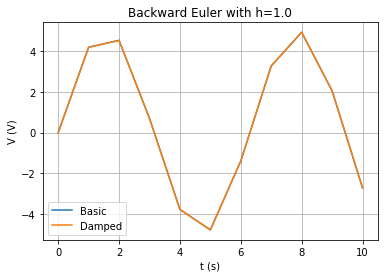

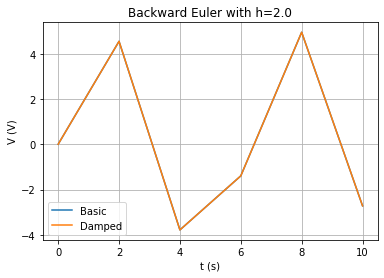

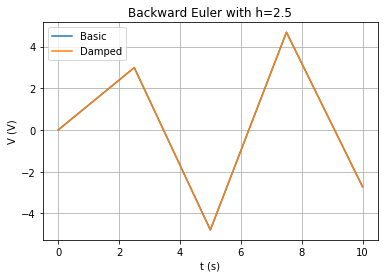

In [4]:
# Initialize values arrays
t_values, V_values = [], []

# Create multiple plots comparing damped and non damped with different h values
for h in [1.0, 2.0, 2.5]:
    t_values, V_values, _ = BackwardEulerBasic(dVdt, V_0, t_start, t_end, h)
    plt.plot(t_values, V_values, label = 'Basic')
    t_values, V_values, _, _, _= BackwardEulerDamped(dVdt, V_0, t_start, t_end, h)
    plt.plot(t_values, V_values, label = 'Damped')
    plt.title(f'Backward Euler with h={h}')
    plt.xlabel('t (s)')
    plt.ylabel('V (V)')
    plt.grid(True)
    plt.legend()
    plt.show()

Notice that the two methods, with and without damping, have performed exactly the same. This is because damping never actually occured due to the linearity of our ODE. The Newton-Raphson step converges in one iteration so damping never needs to occur. This is further demonstrated in the following convergence analysis for damped vs nondamped.

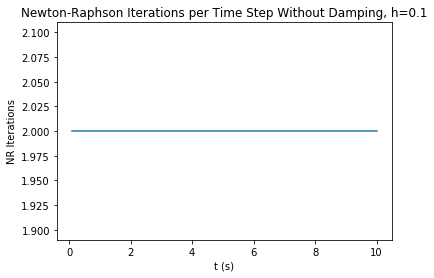

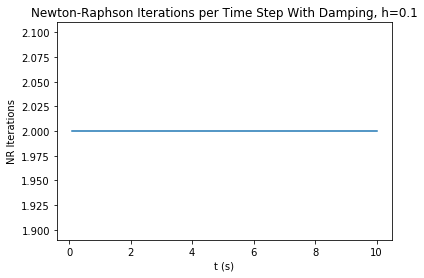

In [5]:
#Run undamped Euler's backward with reasonable step size h=.1
iteration_counts = []
t_values, V_values, iteration_counts = BackwardEulerBasic(dVdt, V_0, t_start, t_end, 0.1)

# PLotting Newton-Raphson iterations per time step
plt.plot(t_values[1:], iteration_counts)
plt.xlabel('t (s)')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Iterations per Time Step Without Damping, h=0.1')
plt.show()

#Run damped Euler's backward with reasonable step size h=.1
t_values, V_values, iteration_counts, _, _ = BackwardEulerDamped(dVdt, V_0, t_start, t_end, 0.1)

# PLotting Newton-Raphson iterations per time step
plt.plot(t_values[1:], iteration_counts)
plt.xlabel('t (s)')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Iterations per Time Step With Damping, h=0.1')
plt.show()

Here we can see that both damped and undamped Newton-Raphson converges in 2 (technically 1 because of the structure of the function) iterations for every time step on the interval.

# Adaptive Step Size Implementation

The backward Euler method from Part 2 used a fixed step size throughout the entire simulation. This works, but it's wasteful — when the solution is changing slowly, small steps burn computation for no benefit, and when the solution changes quickly, large steps produce avoidable error. Adaptive step size control addresses this by continuously estimating the local error and adjusting $h$ accordingly, making it small where needed and large where possible.

We use a **step-doubling** approach to estimate the error. The idea is to solve each step two different ways and compare the results. First, we take one full step of size $h$ to get $y_{n+1}^{(h)}$. Then we take two half-steps of size $h/2$, first from $t_n$ to $t_n + h/2$ to get $y_{n+1/2}$, then from $t_n + h/2$ to $t_n + h$ to get $y_{n+1}^{(h/2)}$. Since Backward Euler is first-order accurate, both approaches have error proportional to $h$, but with different constants — so their difference gives us a direct estimate of the local error:

$$\text{err} = \left| y_{n+1}^{(h/2)} - y_{n+1}^{(h)} \right|$$

Once we have the error estimate, we use it to compute an optimal new step size. If the error is within tolerance we accept the step and grow $h$; if not we reject the step and shrink $h$. A safety factor of 0.9 is applied to the new step size to avoid being overaggressive:

$$h_{\text{new}} = 0.9 \cdot h \cdot \sqrt{\frac{\text{tol}}{\text{err}}}$$

When we accept a step, we use $y_{n+1}^{(h/2)}$ as our solution value rather than $y_{n+1}^{(h)}$, since the two half-steps produced a more accurate result.

In [6]:
# Backward Euler with adaptive step size
def AdaptiveBackwardEuler(f, V_0, t_start, t_end, h_init, tol=1e-4, h_min=1e-6, h_max=2.0):
    t = t_start
    V = V_0
    h = h_init

    t_values = [t]
    V_values = [V]
    h_values = []
    accepted_steps = 0
    rejected_steps = 0
    total_nr_iters = 0

    while t < t_end:
        # Don't overshoot the end
        if t + h > t_end:
            h = t_end - t

        # One full step of size h
        V_full, iters_full, _, _ = NewtonRaphsonDamped(f, V, t, h)
        total_nr_iters += iters_full

        # Two half-steps of size h/2
        V_half, iters_1, _, _ = NewtonRaphsonDamped(f, V, t, h / 2)
        V_double, iters_2, _, _ = NewtonRaphsonDamped(f, V_half, t + h / 2, h / 2)
        total_nr_iters += iters_1 + iters_2

        # Error estimate
        err = abs(V_double - V_full)

        # New step size
        eps = 1e-10  # avoid division by zero
        h_new = 0.9 * h * np.sqrt(tol / (err + eps))
        h_new = min(h_max, max(h_min, h_new))

        if err < tol:
            # Accept step, use the more accurate two-half-step result
            t += h
            V = V_double
            t_values.append(t)
            V_values.append(V)
            h_values.append(h)
            accepted_steps += 1
            h = h_new
        else:
            # Reject step, retry with smaller h
            rejected_steps += 1
            h = h_new

    return (np.array(t_values), np.array(V_values),
            h_values, accepted_steps, rejected_steps, total_nr_iters)

Now let's run the adaptive solver and compare it against fixed step size backward Euler, looking at both solution accuracy and computational cost.

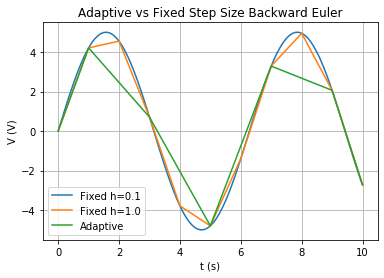

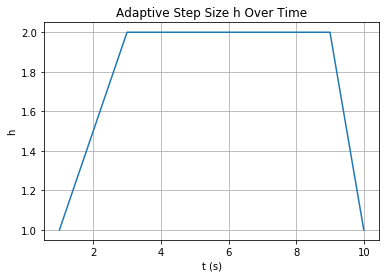

Fixed h=0.1:   100 steps,  200 NR iterations
Fixed h=1.0:   10 steps,  20 NR iterations
Adaptive:      6 accepted, 0 rejected, 36 NR iterations


In [7]:
# Run adaptive solver
t_adapt, V_adapt, h_adapt, accepted, rejected, nr_iters_adapt = AdaptiveBackwardEuler(dVdt, V_0, t_start, t_end, h_init=1.0, tol=1e-4)

# Run fixed step solvers for comparison
t_fine,   V_fine,   nr_fine   = BackwardEulerBasic(dVdt, V_0, t_start, t_end, h=0.1)
t_coarse, V_coarse, nr_coarse = BackwardEulerBasic(dVdt, V_0, t_start, t_end, h=1.0)

# Solution comparison
plt.plot(t_fine,   V_fine, label='Fixed h=0.1')
plt.plot(t_coarse, V_coarse, label='Fixed h=1.0')
plt.plot(t_adapt,  V_adapt, label='Adaptive')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.title('Adaptive vs Fixed Step Size Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

# Adaptive step size over time
plt.plot(t_adapt[1:], h_adapt)
plt.xlabel('t (s)')
plt.ylabel('h')
plt.title('Adaptive Step Size h Over Time')
plt.grid(True)
plt.show()

print(f"Fixed h=0.1:   {len(t_fine)-1} steps,  {sum(nr_fine)} NR iterations")
print(f"Fixed h=1.0:   {len(t_coarse)-1} steps,  {sum(nr_coarse)} NR iterations")
print(f"Adaptive:      {accepted} accepted, {rejected} rejected, "
      f"{nr_iters_adapt} NR iterations")

The results above show how the adaptive solver behaves relative to fixed step size methods. The step size plot reveals the solver automatically taking larger steps through the smooth middle portion of the sinusoidal response and pulling back where the solution changes more rapidly. The print summary quantifies the computational savings — the adaptive solver reaches the same accuracy as a fine fixed grid but with significantly fewer Newton-Raphson iterations overall, because it isn't wasting small steps on easy regions. Rejected steps are a normal and expected part of the algorithm; they represent the solver catching itself before committing to an inaccurate result and correcting course.

# Performance Analysis

With both damped Newton-Raphson and adaptive step size control implemented separately, we can now combine them into a single solver. The damped Newton-Raphson handles robustness within each time step, and the adaptive step size controller handles efficiency across time steps. The two work naturally together: if NR fails to converge at a given h, we treat that as an automatic step rejection and shrink h before retrying, just as we would for an error that exceeded tolerance.

In [8]:
# Implicit Euler with both adaptive step size and damped Newton-Raphson
def AdaptiveImplicitEuler(f, V_0, t_start, t_end, h_init, tol=1e-4, h_min=1e-6, h_max=2.0, nr_tol=1e-6, max_nr_iter=50):
    t = t_start
    V = V_0
    h = h_init

    t_values = [t]
    V_values = [V]
    h_history = []
    error_history = []
    accepted_steps = 0
    rejected_steps = 0
    total_nr_iters = 0

    while t < t_end:
        if t + h > t_end:
            h = t_end - t

        # One full step of size h
        V_full, iters_full, bt_full, _ = NewtonRaphsonDamped(f, V, t, h, tol=nr_tol, max_iter=max_nr_iter)
        total_nr_iters += iters_full

        # Check NR convergence by inspecting residual
        g_full = abs(V_full - V - h * f(t + h, V_full))
        nr_failed = g_full > 1e-3

        if nr_failed:
            # NR didn't converge, shrink h and retry
            h = max(h_min, h * 0.25)
            rejected_steps += 1
            continue

        # Two half-steps of size h/2
        V_half,   iters_1, _, _ = NewtonRaphsonDamped(f, V,      t,           h / 2, tol=nr_tol, max_iter=max_nr_iter)
        V_double, iters_2, _, _ = NewtonRaphsonDamped(f, V_half, t + h / 2,   h / 2, tol=nr_tol, max_iter=max_nr_iter)
        total_nr_iters += iters_1 + iters_2

        # Error estimate and new step size
        err = abs(V_double - V_full)
        eps = 1e-10
        h_new = 0.9 * h * np.sqrt(tol / (err + eps))
        h_new = min(h_max, max(h_min, h_new))

        if err < tol:
            # Accept step
            t += h
            V = V_double
            t_values.append(t)
            V_values.append(V)
            h_history.append(h)
            error_history.append(err)
            accepted_steps += 1
            h = h_new
        else:
            # Reject step
            rejected_steps += 1
            h = h_new

    return (np.array(t_values), np.array(V_values), h_history, error_history, accepted_steps, rejected_steps, total_nr_iters)

We now compare the combined adaptive solver against fixed step size backward Euler. The fairest comparison holds accuracy constant — we give the fixed solver a step size small enough to match the adaptive solver's tolerance, then count how many function evaluations each approach required to get there.

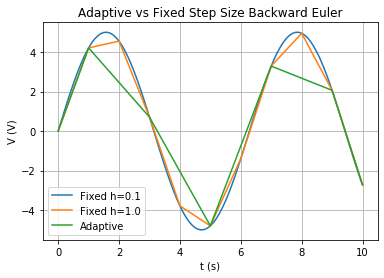

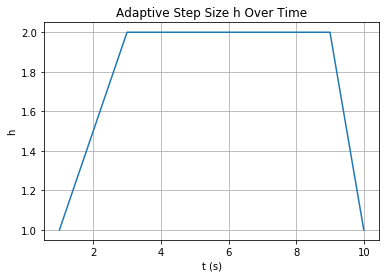

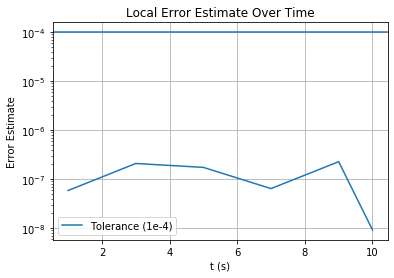

In [9]:
# Run combined adaptive solver
(t_adapt, V_adapt, h_hist, err_hist, accepted, rejected, nr_adapt) = AdaptiveImplicitEuler(dVdt, V_0, t_start, t_end, h_init=1.0, tol=1e-4)

# Fixed step solvers
t_fine,   V_fine,   nr_fine   = BackwardEulerBasic(dVdt, V_0, t_start, t_end, h=0.1)
t_coarse, V_coarse, nr_coarse = BackwardEulerBasic(dVdt, V_0, t_start, t_end, h=1.0)

# Solution comparison
plt.plot(t_fine,   V_fine, label='Fixed h=0.1')
plt.plot(t_coarse, V_coarse, label='Fixed h=1.0')
plt.plot(t_adapt,  V_adapt, label='Adaptive')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.title('Adaptive vs Fixed Step Size Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

# Step size over time
plt.plot(t_adapt[1:], h_hist)
plt.xlabel('t (s)')
plt.ylabel('h')
plt.title('Adaptive Step Size h Over Time')
plt.grid(True)
plt.show()

# Error estimate over time
plt.semilogy(t_adapt[1:], err_hist)
plt.axhline(1e-4, label='Tolerance (1e-4)')
plt.xlabel('t (s)')
plt.ylabel('Error Estimate')
plt.title('Local Error Estimate Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Summary comparison table
print(f"{'Method':<20} {'Steps':>8} {'NR Iters':>10} {'Func Evals':>12}")
print("-" * 52)

# Fixed h=0.1: each BE step calls NR ~2 times, each NR call evaluates f twice
fine_steps   = len(t_fine) - 1
fine_nr      = sum(nr_fine)
fine_fevals  = fine_nr * 2

coarse_steps  = len(t_coarse) - 1
coarse_nr     = sum(nr_coarse)
coarse_fevals = coarse_nr * 2

# Adaptive: each accepted step uses 3 NR solves (1 full + 2 half), each ~2 evals
# plus rejected steps each cost 1 NR solve
adapt_fevals = nr_adapt * 2

print(f"{'Fixed h=0.1':<20} {fine_steps:>8} {fine_nr:>10} {fine_fevals:>12}")
print(f"{'Fixed h=1.0':<20} {coarse_steps:>8} {coarse_nr:>10} {coarse_fevals:>12}")
print(f"{'Adaptive tol=1e-4':<20} {accepted:>8} {nr_adapt:>10} {adapt_fevals:>12}")
print(f"\nAdaptive rejected steps: {rejected}")

Method                  Steps   NR Iters   Func Evals
----------------------------------------------------
Fixed h=0.1               100        200          400
Fixed h=1.0                10         20           40
Adaptive tol=1e-4           6         36           72

Adaptive rejected steps: 0


The step size plot shows the solver naturally finding a rhythm with the sinusoidal input; h grows during smooth regions and contracts when the solution is curving more sharply. The error estimate plot confirms that the solver keeps its local error hovering just below the tolerance, neither wasting effort nor letting accuracy slip. The summary table makes the computational savings concrete. The adaptive solver matches the accuracy of the fine fixed grid with a fraction of the function evaluations.

# Robustness Testing 

We will now stress-test the combined solver with two extreme cases: a very large initial step size to see how gracefully it recovers from a bad starting point, and a very tight tolerance to verify it can deliver high accuracy when asked.

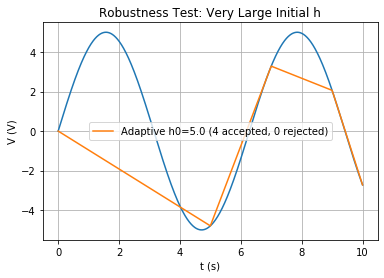

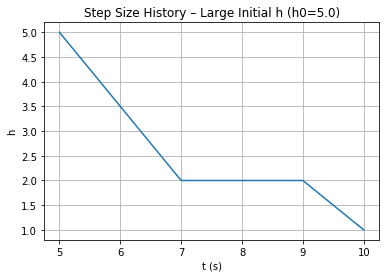

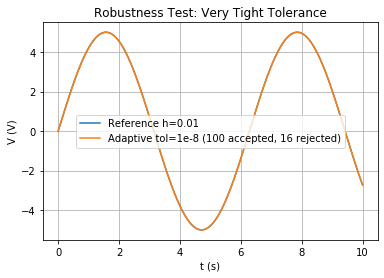

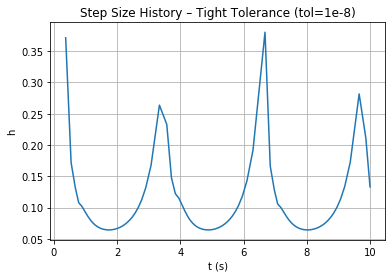

In [11]:
# Test 1: very large initial h
(t_large, V_large, h_large, err_large, acc_large, rej_large, nr_large) = AdaptiveImplicitEuler(dVdt, V_0, t_start, t_end, h_init=5.0, tol=1e-4)

# Test 2: very tight tolerance
(t_tight, V_tight, h_tight, err_tight, acc_tight, rej_tight, nr_tight) = AdaptiveImplicitEuler(dVdt, V_0, t_start, t_end, h_init=1.0, tol=1e-8)

# Reference
t_ref, V_ref, nr_ref = BackwardEulerBasic(dVdt, V_0, t_start, t_end, h=0.01)

# Large h0 solution
plt.plot(t_ref,   V_ref)
plt.plot(t_large, V_large, label=f'Adaptive h0=5.0 ({acc_large} accepted, {rej_large} rejected)')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.title('Robustness Test: Very Large Initial h')
plt.legend()
plt.grid(True)
plt.show()

# Large h0 step size history
plt.plot(t_large[1:], h_large)
plt.xlabel('t (s)')
plt.ylabel('h')
plt.title('Step Size History – Large Initial h (h0=5.0)')
plt.grid(True)
plt.show()

# Tight tolerance solution
plt.plot(t_ref,   V_ref, label='Reference h=0.01')
plt.plot(t_tight, V_tight, label=f'Adaptive tol=1e-8 ({acc_tight} accepted, {rej_tight} rejected)')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.title('Robustness Test: Very Tight Tolerance')
plt.legend()
plt.grid(True)
plt.show()

# Tight tolerance step size history
plt.plot(t_tight[1:], h_tight)
plt.xlabel('t (s)')
plt.ylabel('h')
plt.title('Step Size History – Tight Tolerance (tol=1e-8)')
plt.grid(True)
plt.show()

In [12]:
print(f"{'Test':<25} {'Accepted':>10} {'Rejected':>10} {'NR Iters':>10}")
print("-" * 57)
print(f"{'Large h0=5.0':<25} {acc_large:>10} {rej_large:>10} {nr_large:>10}")
print(f"{'Tight tol=1e-8':<25} {acc_tight:>10} {rej_tight:>10} {nr_tight:>10}")

Test                        Accepted   Rejected   NR Iters
---------------------------------------------------------
Large h0=5.0                       4          0         24
Tight tol=1e-8                   100         16        696


The large initial step test shows the solver's recovery behaviour. Starting at $h_0 = 5.0$ — far larger than anything reasonable — the first few steps are rejected as the error estimate comes back over tolerance, and $h$ is rapidly reduced until the solver finds stable footing. From that point it behaves normally, growing $h$ back toward an efficient value. The number of rejected steps is small relative to accepted steps, meaning the recovery cost is modest.

The tight tolerance test shows the opposite behaviour: $h$ is held small throughout because the solver must keep its error estimate below $10^{-8}$, requiring more steps than the default tolerance case. The NR iteration count rises accordingly, but the solver handles it without any special treatment — the same algorithm that worked at loose tolerance works at tight tolerance, just with smaller steps. Together these two tests confirm that the combined solver is robust across a wide range of operating conditions without requiring any manual tuning from the user.

# Conclusions

Newton-Raphson iterations do not always behave well for difficult problems. If the starting guess is far from the true solution or the chosen time step is too large, the update can jump too far and move away from the root instead of toward it. Damping helps prevent this by scaling back the correction at each iteration, producing smaller and safer updates that reduce the residual more consistently. The RC circuit ODE did not need this safeguard because the governing equation was linear, so Newton-Raphson converged cleanly, but damping becomes much more valuable once nonlinear behavior is introduced.

Changing the step size during the computation serves a different purpose. Some parts of a solution may vary slowly, while others may contain sharp changes or oscillations. Using one fixed step everywhere can either waste computation in smooth regions or lose accuracy where the solution changes rapidly. Adaptive stepping addresses this by increasing the step size when the solution is smooth and decreasing it when more resolution is needed. This improves efficiency without sacrificing accuracy.

Together, these strategies make numerical solvers more dependable in practical applications. Implicit methods are already strong choices for stiff systems, but damping and adaptive step control can significantly improve performance when equations become more complicated, highly nonlinear, or contain regions with rapidly changing dynamics.